In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from tqdm import tqdm
#import contextily as ctxv
import osmnx as ox
from osmnx import graph_to_gdfs
from shapely.ops import unary_union
from shapely.geometry import MultiPoint
import logging 
from geopandas import sjoin
import pickle
ox.settings.log_console = True

In [2]:
from shapely.geometry import Polygon, MultiPoint
import math
import libpysal
# from sklearn.cluster import AgglomerativeClustering # Not used if using adaptive regionalization
from tqdm.auto import tqdm
import logging
import pickle
import matplotlib.pyplot as plt
from libpysal.weights import KNN, DistanceBand, Queen # Queen for low-density merging
from matplotlib.colors import LogNorm, Normalize
import numpy as np # For np.nan checking if needed, though fillna is better

# --- Initial Setup ---
logging.basicConfig(level=logging.INFO, # Changed to INFO for less verbose default, DEBUG for dev
                    format='%(asctime)s - %(levelname)s - %(filename)s:%(lineno)d - %(message)s')

ox.settings.log_console = True
logging.info("Script started.")

2025-06-11 15:17:41,508 - INFO - 2105997383.py:18 - Script started.


In [3]:

#FL_df = pd.read_csv("FL_poi_subset.csv")

In [4]:
logging.info("Step 1: Loading data and creating initial GeoDataFrame...")
df = pd.read_csv("hurricane_matrix.csv")
df.head()
df = df.rename(columns={"Unnamed: 0": "traj_id"})
# 2.2. Set traj_id as the DataFrame index
df = df.set_index("traj_id")
df_long = df.stack().rename("coords").reset_index()

df_long = df_long.rename(columns={"level_1": "pt_idx"})
print(df_long)

2025-06-11 15:17:42,009 - INFO - 1812683755.py:1 - Step 1: Loading data and creating initial GeoDataFrame...


                                                   traj_id pt_idx  \
0        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      1   
1        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      3   
2        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      5   
3        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...     20   
4        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...     21   
...                                                    ...    ...   
1677305  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...    130   
1677306  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...    133   
1677307  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...    134   
1677308  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...    140   
1677309  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...    141   

                          coords  
0        (24.548312, -81.796707)  
1        (24.548324, -81.796739)  
2        (24.548307, -81.796648)  
3        (26.451009, -81.949365

In [5]:
import ast

# (A) Define a helper that tries to literal_eval the string,
#     and falls back to (nan, nan) on any failure.
def parse_coord_string(s):
    """
    Convert a string '(lat, lon)' into a (float(lat), float(lon)) tuple.
    If parsing fails, return (nan, nan).
    """
    if not isinstance(s, str):
        # If somehow it's already a tuple/list, cast its elements to float
        if isinstance(s, (tuple, list)) and len(s) == 2:
            try:
                return (float(s[0]), float(s[1]))
            except:
                return (np.nan, np.nan)
        return (np.nan, np.nan)

    try:
        # literal_eval safely parses Python literal syntax
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (tuple, list)) and len(parsed) == 2:
            lat, lon = float(parsed[0]), float(parsed[1])
            return (lat, lon)
        else:
            return (np.nan, np.nan)
    except Exception:
        return (np.nan, np.nan)
print(df_long)
# (B) Apply this to your entire df_long["coords"] column
df_long["coords"] = df_long["coords"].apply(parse_coord_string)

# (C) Verify all entries are now tuples of two floats
print("After parsing, types in df_long['coords']:")
print(df_long["coords"].apply(type).value_counts())

                                                   traj_id pt_idx  \
0        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      1   
1        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      3   
2        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      5   
3        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...     20   
4        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...     21   
...                                                    ...    ...   
1677305  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...    130   
1677306  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...    133   
1677307  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...    134   
1677308  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...    140   
1677309  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...    141   

                          coords  
0        (24.548312, -81.796707)  
1        (24.548324, -81.796739)  
2        (24.548307, -81.796648)  
3        (26.451009, -81.949365

In [6]:
bad_coords = df_long["coords"].apply(lambda x: not (isinstance(x, (tuple, list)) and len(x) == 2))
if bad_coords.any():
    # If any row is not a 2‐tuple, inspect them:
    print("Rows with malformed coords:")
    print(df_long.loc[bad_coords, :].head())
    raise ValueError("Some coords are not length‐2 tuples. Please inspect your data.")
else:
    logging.info("All coords appear to be 2‐element tuples. Proceed to unpack.")

# 4.2. Unpack into two new columns, latitude & longitude
df_long[["latitude", "longitude"]] = pd.DataFrame(
    df_long["coords"].tolist(), index=df_long.index, columns=["latitude", "longitude"]
)
df_long = df_long.drop(columns="coords")

# 4.3. Convert pt_idx (if it’s still a string) into an integer from 1..144
#      If your original wide columns were strings '1','2',… you can safely convert:
try:
    df_long["pt_idx"] = df_long["pt_idx"].astype(int)
except ValueError:
    # If pt_idx cannot cast to int (e.g. if columns were named "STEP1"), leave as-is
    pass

print("After unpacking, columns of df_long:", df_long.columns.tolist())
print(df_long)

2025-06-11 15:17:57,931 - INFO - 2322511903.py:8 - All coords appear to be 2‐element tuples. Proceed to unpack.


After unpacking, columns of df_long: ['traj_id', 'pt_idx', 'latitude', 'longitude']
                                                   traj_id  pt_idx   latitude  \
0        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       1  24.548312   
1        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       3  24.548324   
2        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       5  24.548307   
3        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      20  26.451009   
4        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      21  26.451007   
...                                                    ...     ...        ...   
1677305  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     130  29.942492   
1677306  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     133  30.080000   
1677307  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     134  30.080000   
1677308  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     140  29.944345   
1677309  559f9e9acaaf7e32

In [7]:
df_long["geometry"] = df_long.apply(
    lambda r: Point(r.longitude, r.latitude),
    axis=1
)
point_gdf = gpd.GeoDataFrame(
    df_long[["traj_id", "pt_idx", "latitude", "longitude", "geometry"]],
    geometry="geometry",
    crs="EPSG:4326"
)
logging.info(f"Built point_gdf with {len(point_gdf)} points.")


2025-06-11 15:18:21,303 - INFO - 554215537.py:10 - Built point_gdf with 1677310 points.


In [8]:
with open("point_gdf_raw.pickle","wb") as f:
    pickle.dump(point_gdf,f)

In [9]:
with open("point_gdf_raw.pickle","rb") as f:
    point_gdf = pickle.load(f)

In [10]:
## We can load from Hex_cent.
# ————————————————————————————————————————————————
list_points = []
for xy in tqdm(zip(df_long.longitude, df_long.latitude), desc="Preparing points for hull", total=len(df)):
    list_points.append((xy[0],xy[1]))

if not list_points or len(list_points) < 3:
    logging.error("Not enough points (<3) for hull. Exiting.")
    exit()

all_points_multipoint = MultiPoint(list_points)
points_crs = point_gdf.crs
s = gpd.GeoSeries([all_points_multipoint], crs=points_crs)

concavity_ratio = 0.05
allow_holes_param = False
logging.info(f"Creating GeoPandas concave hull with ratio={concavity_ratio} and allow_holes={allow_holes_param}...")
study_poly = None
study_poly_geoseries = s.concave_hull(ratio=concavity_ratio, allow_holes=allow_holes_param)
if not study_poly_geoseries.empty and study_poly_geoseries.iloc[0] is not None and not study_poly_geoseries.iloc[0].is_empty:
    study_poly = study_poly_geoseries.iloc[0] # returns the polygon of concave hull

Preparing points for hull:   0%|          | 0/95410 [00:00<?, ?it/s]

2025-06-11 15:18:40,756 - INFO - 4063424718.py:17 - Creating GeoPandas concave hull with ratio=0.05 and allow_holes=False...


In [11]:
hex_gdf=gpd.read_parquet("Hex_tesse_raw.parquet")

In [197]:
hex_gdf = pd.read_parquet("Hex_tesse_raw.parquet")
hex_gdf = hex_gdf.reset_index(drop=True)  

# 2) Create a hex_id column (string or integer) from that index
#    You can keep it as an integer, or convert to string, e.g. "H0", "H1", ...
hex_gdf["hex_id"] = hex_gdf.index.astype(str)

# Let’s say hex_df["geometry"] is dtype=object of WKB bytes.
hex_gdf["geometry"] = gpd.GeoSeries.from_wkb(hex_gdf["geometry"])
# Now convert to a GeoDataFrame:
hex_gdf = gpd.GeoDataFrame(hex_gdf, geometry="geometry", crs="EPSG:4326")

print(hex_gdf.head())



                                            geometry hex_id
0  POLYGON ((-81.8 24.45908, -81.79741 24.4546, -...      0
1  POLYGON ((-81.795 24.45908, -81.79236 24.45908...      1
2  POLYGON ((-81.8175 24.4764, -81.8075 24.4764, ...      2
3  POLYGON ((-81.7925 24.45908, -81.8025 24.45908...      3
4  POLYGON ((-81.7925 24.46774, -81.7875 24.4764,...      4


<Axes: >

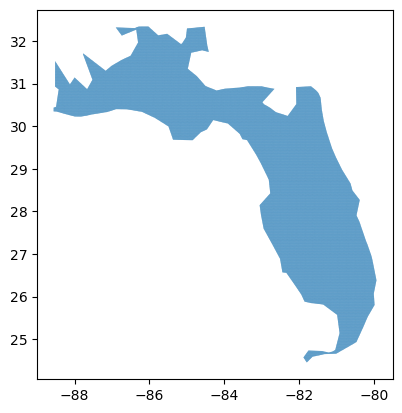

In [13]:
hex_gdf.plot()

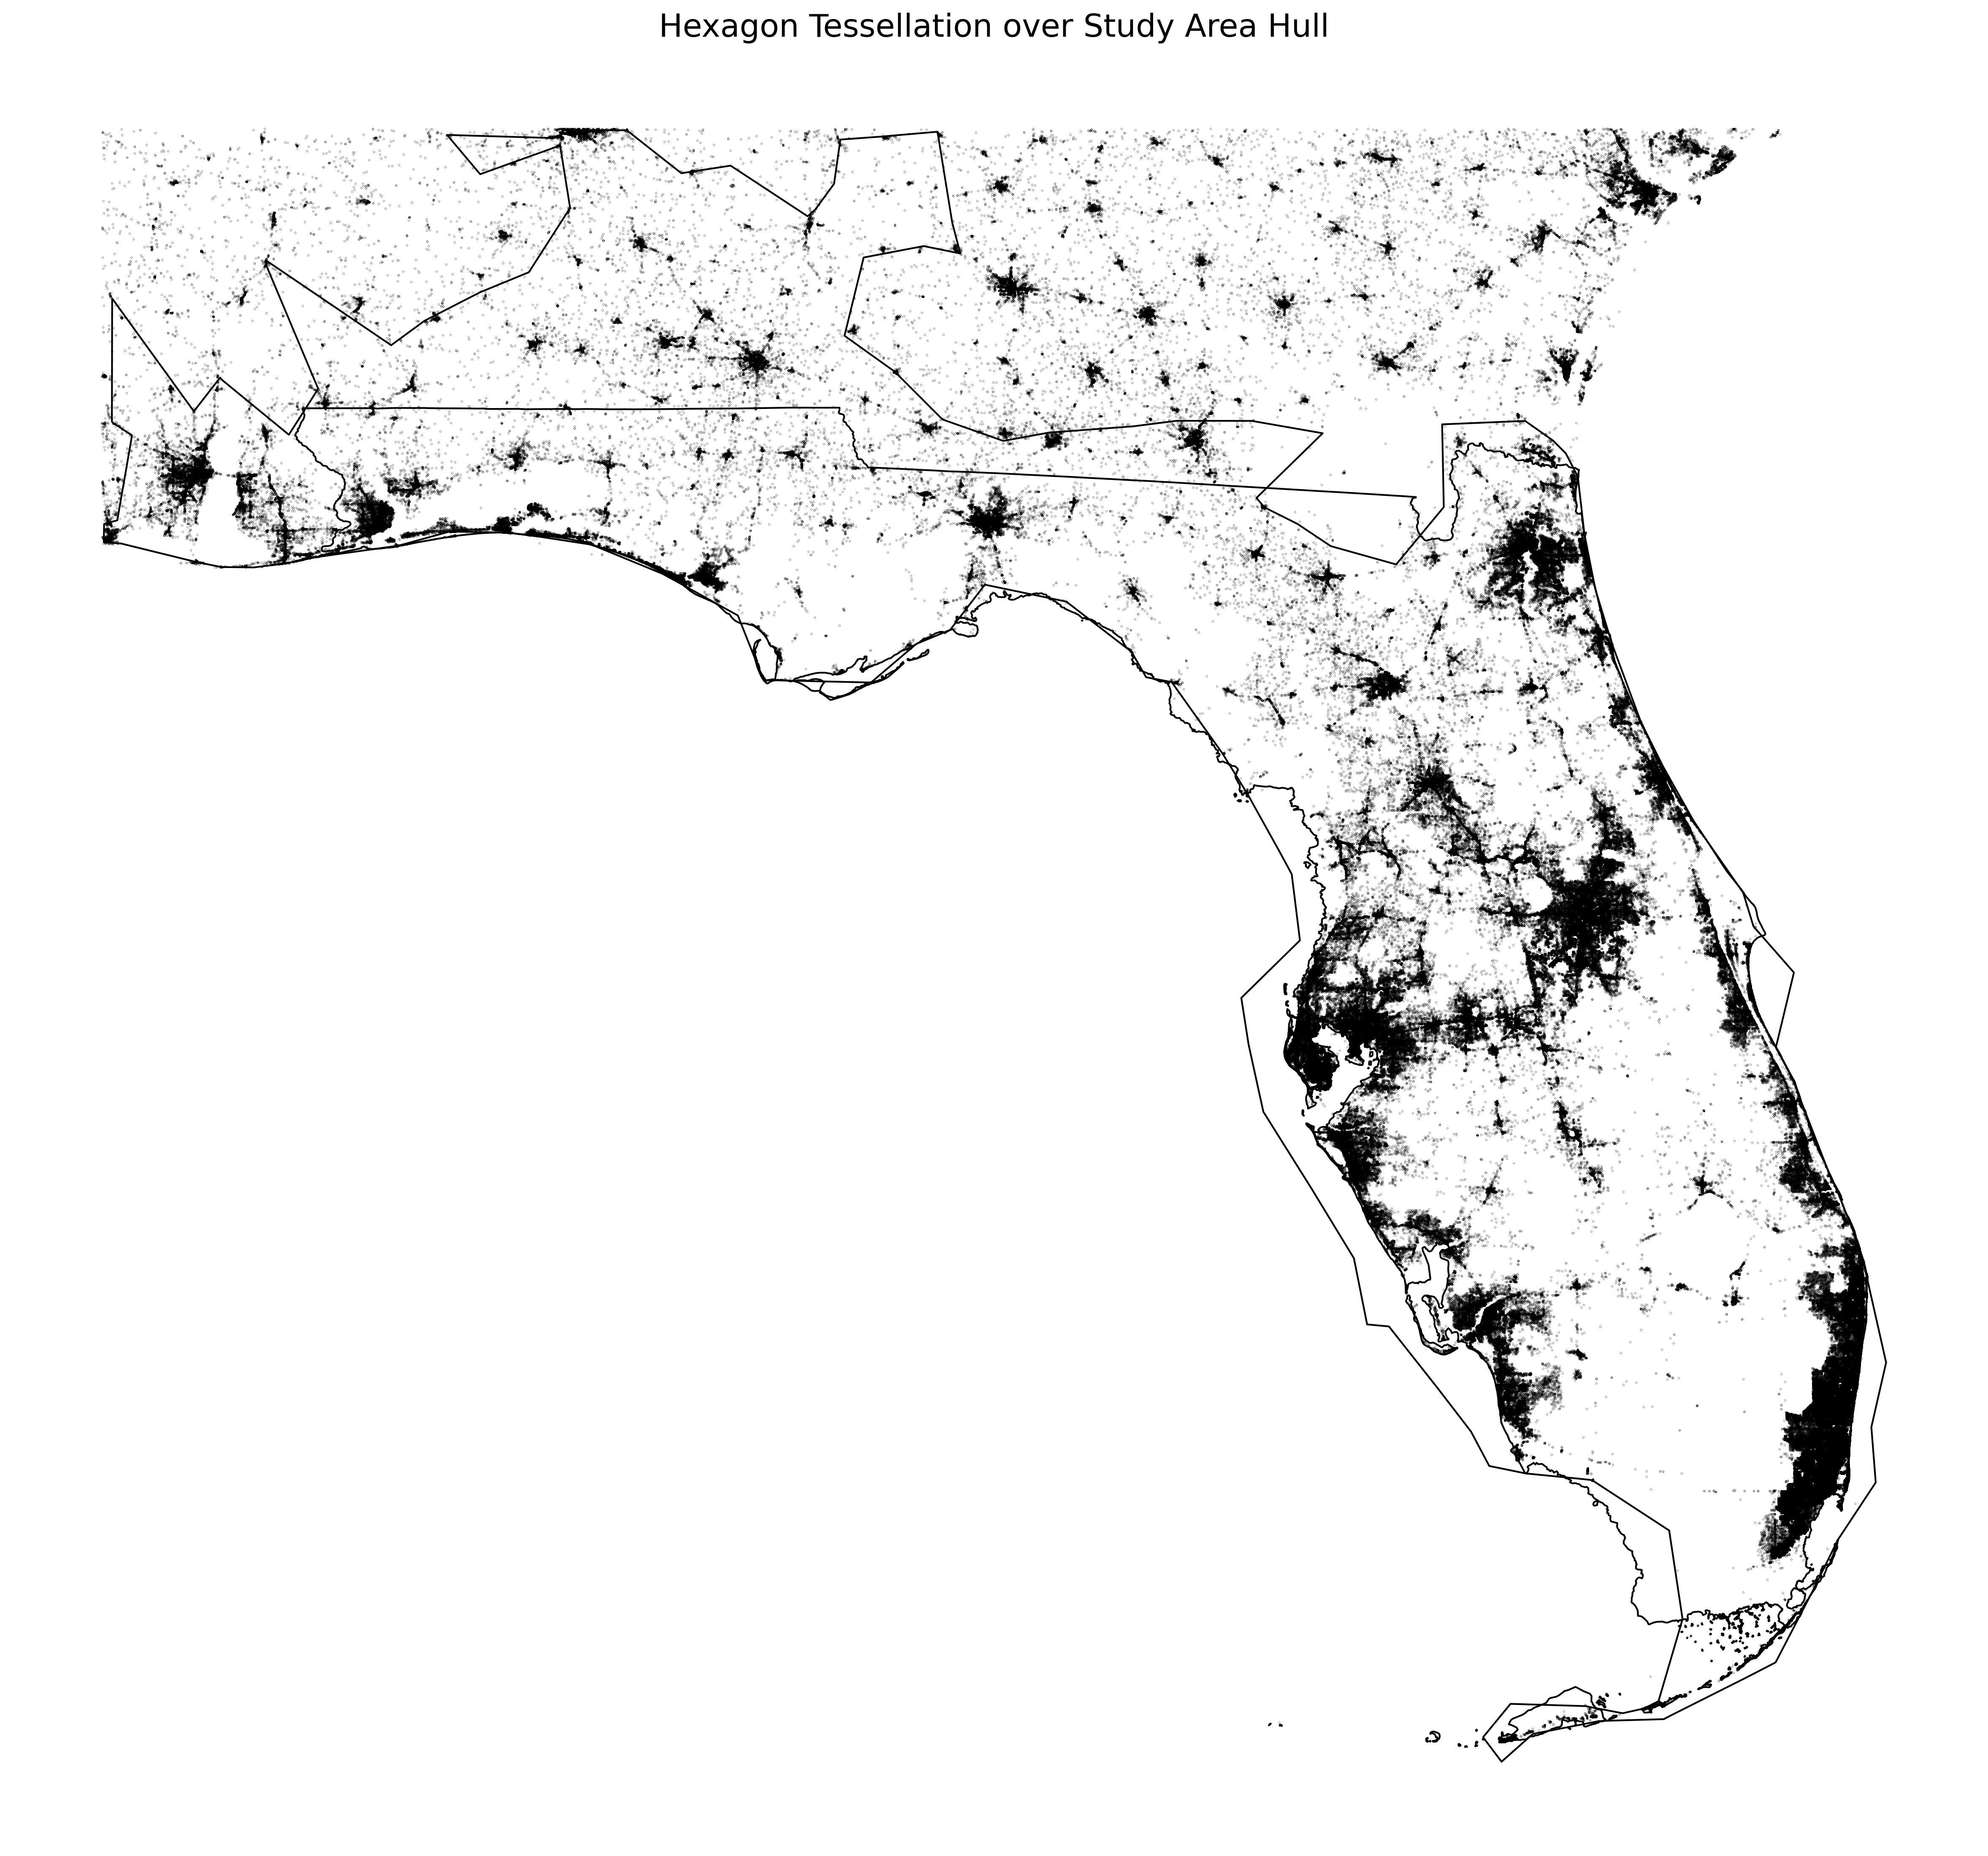

In [14]:
FL_POI_DS = pd.read_csv("Hex_bound_POI.csv")
FL_POI_DS["geometry"] = gpd.points_from_xy(
    FL_POI_DS["LONGITUDE"].astype(float),
    FL_POI_DS["LATITUDE"].astype(float)
)

# 2. If FL_POI_DS was not already a GeoDataFrame, turn it into one:
FL_POI_GDF = gpd.GeoDataFrame(
    FL_POI_DS,
    geometry="geometry",
    crs="EPSG:4326"   # (or whatever CRS these lon/lat coordinates use)
)
FL_POI_GDF.head

import matplotlib.pyplot as plt
import geopandas as gpd
states = gpd.read_file('cb_2018_us_state_500k.shp')
# Assuming hex_gdf and study_poly are already defined in the environment.
# If study_poly is a Shapely polygon, convert to GeoDataFrame:
hull_gdf = gpd.GeoDataFrame({'geometry': [study_poly]}, crs=hex_gdf.crs)

# Create an ultra-high-definition figure
fig, ax = plt.subplots(figsize=(20, 20), dpi=300)

# Plot the hull boundary
hull_gdf.boundary.plot(ax=ax, color='black', linewidth=1)
states[states.STUSPS=="FL"].boundary.plot(ax=ax, color='black', linewidth=1)
# Plot all hexagon boundaries
#hex_gdf.boundary.plot(ax=ax, edgecolor='gray', linewidth=0.3)
FL_POI_GDF.plot(ax=ax,markersize=0.01,
                       color="black")
# Optional: fill the hull lightly for context
#hull_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

ax.set_aspect('equal')
ax.set_axis_off()
plt.title("Hexagon Tessellation over Study Area Hull", fontsize=18)
plt.show()


In [15]:
FL_POI_GDF.within(hex_gdf)

/tmp/311801.tmpdir/ipykernel_644/529286532.py:1: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  FL_POI_GDF.within(hex_gdf)


0          False
1          False
2          False
3          False
4          False
           ...  
1642499    False
1642500    False
1642501    False
1642502    False
1642503    False
Length: 1642504, dtype: bool

In [16]:
mask = FL_POI_GDF.within(study_poly)
Hull_FL_POI_GDF=FL_POI_GDF[mask].reset_index()
print(Hull_FL_POI_GDF)

           index  Unnamed: 0             PLACEKEY  LONGITUDE   LATITUDE  \
0              0           4  zzy-22s@8dj-jv6-ks5 -82.524818  27.949076   
1              1           6  zzy-22s@8gp-3nn-3dv -81.380769  30.199156   
2              2          12  zzy-22t@8dh-h4q-gx5 -81.769293  24.566605   
3              3          27  zzy-234@8gp-2dc-fj9 -81.682551  30.203123   
4              4         157  zzz-222@8dg-kpy-btv -81.847107  26.642022   
...          ...         ...                  ...        ...        ...   
1548012  1642499    20309583  zzy-222@8gq-r2j-t5f -81.426410  29.784013   
1548013  1642500    20309584  zzy-222@8gq-tkh-qcq -81.070241  29.217953   
1548014  1642501    20309585  zzy-222@8gq-tsg-5vf -81.322792  29.042548   
1548015  1642502    20309586  zzy-222@8gq-wfw-yd9 -81.019375  29.249829   
1548016  1642503    20309587  zzy-222@8gq-wwk-fj9 -80.988885  29.145973   

                                              concatenated REGION  \
0        Activities Related to

In [198]:
hex_gdf = hex_gdf.set_crs(epsg=4326, allow_override=True)




In [18]:

from sklearn.neighbors import KDTree
import networkx as nx
hex_proj = hex_gdf
coords = np.vstack([
    hex_proj["centroid_x"].values,
    hex_proj["centroid_y"].values
]).T   # shape = (M, 2)

# (5) Construct a KDTree for fast Euclidean nearest‐neighbor in meters
tree = KDTree(coords, metric="euclidean")

# (6) Query k=7 neighbors (index 0 is the hex itself, distance=0)
distances, indices = tree.query(coords, k=9)

M = coords.shape[0]
hex_ids = hex_proj["hex_id"].tolist()

# Build a raw adjacency list (with possible “far” neighbors for boundary hexes)
raw_edge_list = []
raw_distances = []  # to keep track of each edge’s distance
for i in range(M):
    src_id = hex_ids[i]
    for pos in range(1, 7):   # the six closest (excluding itself at index 0)
        j = indices[i, pos]
        dst_id = hex_ids[j]
        raw_edge_list.append((src_id, dst_id))
        raw_distances.append(distances[i, pos])

print("Built raw 6‐NN edge candidates (including very far neighbors).")

first_neighbor_distances = distances[:, 6]  # shape = (M,), these are all > 0
print(len(first_neighbor_distances))
typical_dist = np.median(first_neighbor_distances)
plt.hist((first_neighbor_distances+1e-4),bins=30)
plt.show()
threshold = typical_dist * 1.08
print(f"Typical centroid‐to‐face‐neighbor distance ≈ {typical_dist} m")
print(f"Filtering edges above threshold = {threshold} m")


# (7) Build a filtered edge list
filtered_edges = []
for (u_v, d) in zip(raw_edge_list, raw_distances):
    src_id, dst_id = u_v
    if d <= threshold:
        filtered_edges.append((src_id, dst_id))

print(f"Filtered edges count (unduplicated) = {len(filtered_edges)}")

# (8) Now build the final NetworkX graph (it will dedupe automatically)
G = nx.Graph()
G.add_nodes_from(hex_ids)
G.add_edges_from(filtered_edges)

print("Graph G after distance filtering:")
print("  # nodes =", G.number_of_nodes())
print("  # edges =", G.number_of_edges())

# Check degrees for a few hexes (boundary ones will have <6)
degrees = dict(G.degree())
deg_values = [degrees[h] for h in hex_ids[:10]]  # sample first 10
print("Sample degrees (first 10 hexes):", deg_values)
# (9) Detect which hexes have zero neighbors
isolated_hexes = [h for h, deg in G.degree() if deg == 0]
print(f"Number of isolated hexes: {len(isolated_hexes)}")

# (10) For each isolated hex, find its true nearest neighbor (indices[i,1]), 
#      then add that edge explicitly:


    # 6) Loop will recompute connected components in the next iteration
    

'\nfrom sklearn.neighbors import KDTree\nimport networkx as nx\nhex_proj = hex_gdf\ncoords = np.vstack([\n    hex_proj["centroid_x"].values,\n    hex_proj["centroid_y"].values\n]).T   # shape = (M, 2)\n\n# (5) Construct a KDTree for fast Euclidean nearest‐neighbor in meters\ntree = KDTree(coords, metric="euclidean")\n\n# (6) Query k=7 neighbors (index 0 is the hex itself, distance=0)\ndistances, indices = tree.query(coords, k=9)\n\nM = coords.shape[0]\nhex_ids = hex_proj["hex_id"].tolist()\n\n# Build a raw adjacency list (with possible “far” neighbors for boundary hexes)\nraw_edge_list = []\nraw_distances = []  # to keep track of each edge’s distance\nfor i in range(M):\n    src_id = hex_ids[i]\n    for pos in range(1, 7):   # the six closest (excluding itself at index 0)\n        j = indices[i, pos]\n        dst_id = hex_ids[j]\n        raw_edge_list.append((src_id, dst_id))\n        raw_distances.append(distances[i, pos])\n\nprint("Built raw 6‐NN edge candidates (including very far n

In [19]:
# G can be loaded from graph_store.pickle.
#

for h in isolated_hexes:
    # Find the index i of this hex in hex_ids
    i = hex_ids.index(h)
    # indices[i,1] is the integer‐index of the nearest neighbor (in coords)
    j = indices[i, 1]  
    neighbor_id = hex_ids[j]
    G.add_edge(h, neighbor_id)
    # Optionally, print/log
    print(f"  Connected island hex {h} → nearest {neighbor_id}")

print("After island‐fallback, # edges =", G.number_of_edges())
print("Isolated hexes now (should be 0):", [h for h, d in G.degree() if d == 0])

iteration = 0
while True:
    iteration += 1
    print(f"\nIteration {iteration}:")

    # 1) Find all connected components
    comps = list(nx.connected_components(G))
    comps.sort(key=len, reverse=True)  # sort largest first
    ncomp = len(comps)
    print(f"  Number of connected components: {ncomp}")

    # 2) If only one component remains, we are done
    if ncomp == 1:
        print("  Graph is fully connected. Stopping recursion.")
        break

    # 3) Otherwise, label the largest component as main_comp
    main_comp = comps[0]
    print(f"  Size of main component: {len(main_comp)}")

    # 4) Build a KDTree on main_comp’s centroids for fast lookup
    #    (Reuse the helper function or inline for speed)
    main_ids    = list(main_comp)
    main_coords = np.array([
        (hex_proj.loc[hex_proj.hex_id == h, "centroid_x"].values[0],
         hex_proj.loc[hex_proj.hex_id == h, "centroid_y"].values[0])
        for h in main_ids
    ])
    main_tree   = KDTree(main_coords, metric="euclidean")

    # 5) For each of the *other* components (comps[1:]), find the closest pair to main_comp
    for comp in comps[1:]:
        # comp is a set of hex_ids that is currently disconnected from main_comp
        print(f"  └ Processing component of size {len(comp)}")

        # Find the single best (a, b) pair between comp and main_comp:
        best_a, best_b, best_d = find_closest_pair(comp, main_comp, hex_proj)

        # Add that edge to G, thus merging comp into main_comp
        G.add_edge(best_a, best_b)
        print(f"    → Connected hex {best_a} (component) to {best_b} (main) at distance {best_d:.1f} m")
        

'\nfor h in isolated_hexes:\n    # Find the index i of this hex in hex_ids\n    i = hex_ids.index(h)\n    # indices[i,1] is the integer‐index of the nearest neighbor (in coords)\n    j = indices[i, 1]  \n    neighbor_id = hex_ids[j]\n    G.add_edge(h, neighbor_id)\n    # Optionally, print/log\n    print(f"  Connected island hex {h} → nearest {neighbor_id}")\n\nprint("After island‐fallback, # edges =", G.number_of_edges())\nprint("Isolated hexes now (should be 0):", [h for h, d in G.degree() if d == 0])\n\niteration = 0\nwhile True:\n    iteration += 1\n    print(f"\nIteration {iteration}:")\n\n    # 1) Find all connected components\n    comps = list(nx.connected_components(G))\n    comps.sort(key=len, reverse=True)  # sort largest first\n    ncomp = len(comps)\n    print(f"  Number of connected components: {ncomp}")\n\n    # 2) If only one component remains, we are done\n    if ncomp == 1:\n        print("  Graph is fully connected. Stopping recursion.")\n        break\n\n    # 3) Othe

In [20]:
#with open("graph_store_raw.pickle", 'wb') as f:
#    pickle.dump(G,f)

In [21]:
with open("graph_store_raw.pickle", 'rb') as f:
    G = pickle.load(f)

In [22]:
list(G.edges)[None:10:None]

[('0', '1'),
 ('0', '3'),
 ('0', '2'),
 ('1', '3'),
 ('1', '4'),
 ('1', '2'),
 ('2', '3'),
 ('2', '7'),
 ('2', '6'),
 ('3', '4')]

In [23]:
print("Point bounds:", point_gdf.total_bounds)   # [minx, miny, maxx, maxy]
print("Hex  bounds:  ", hex_gdf.total_bounds)
print(hex_gdf.columns)
print(FL_POI_GDF.columns)
print(point_gdf.columns)


Point bounds: [-88.56     24.45176 -79.94085  32.34301]
Hex  bounds:   [-88.56     24.45176 -79.94085  32.34301]
Index(['geometry', 'hex_id', 'centroid', 'centroid_x', 'centroid_y'], dtype='object')
Index(['Unnamed: 0', 'PLACEKEY', 'LONGITUDE', 'LATITUDE', 'concatenated',
       'REGION', 'LOCATION_NAME', 'geometry'],
      dtype='object')
Index(['traj_id', 'pt_idx', 'latitude', 'longitude', 'geometry'], dtype='object')


In [24]:
FL_POI_GDF.head

<bound method NDFrame.head of          Unnamed: 0             PLACEKEY  LONGITUDE   LATITUDE  \
0                 4  zzy-22s@8dj-jv6-ks5 -82.524818  27.949076   
1                 6  zzy-22s@8gp-3nn-3dv -81.380769  30.199156   
2                12  zzy-22t@8dh-h4q-gx5 -81.769293  24.566605   
3                27  zzy-234@8gp-2dc-fj9 -81.682551  30.203123   
4               157  zzz-222@8dg-kpy-btv -81.847107  26.642022   
...             ...                  ...        ...        ...   
1642499    20309583  zzy-222@8gq-r2j-t5f -81.426410  29.784013   
1642500    20309584  zzy-222@8gq-tkh-qcq -81.070241  29.217953   
1642501    20309585  zzy-222@8gq-tsg-5vf -81.322792  29.042548   
1642502    20309586  zzy-222@8gq-wfw-yd9 -81.019375  29.249829   
1642503    20309587  zzy-222@8gq-wwk-fj9 -80.988885  29.145973   

                                              concatenated REGION  \
0        Activities Related to Real Estate[sep]Resident...     FL   
1        Offices of Real Estate Agents 

In [199]:
#Hull_FL_POI_GDF['geometry'] = Hull_FL_POI_GDF['geometry'].apply(wkt.loads)

Hull_FL_POI_GDF = gpd.GeoDataFrame(Hull_FL_POI_GDF,geometry="geometry", crs="EPSG:4326")
Hull_proj = Hull_FL_POI_GDF.to_crs(epsg=5070)
hex_proj  = hex_gdf.to_crs(epsg=5070)

# 2) Do the nearest‐neighbor join in projected space
joined_proj = gpd.sjoin_nearest(
    Hull_proj[['concatenated','geometry']],
    hex_proj[['hex_id','geometry','centroid']],
    how='right',
    distance_col='dist_m'    # optional: records the actual distance in meters
)

# 3) If you need the joined table back in lon/lat:
joined_ll = joined_proj.to_crs(epsg=4326)

# 4) Clean up (drop the auto‐indices, etc.)
joined = (
    joined_ll
      .drop(columns=['index_left'])
      #.set_index('hex_id')
)

# Diagnostics
print("Total points:   ", len(Hull_FL_POI_GDF))
print("Matched points: ", joined['concatenated'].notna().sum())
print("Unmatched pts:  ", joined['concatenated'].isna().sum())
matched_points = joined[joined["hex_id"].notna()]

# If you want one row per hex_id, you can now aggregate matched_points by hex_id:
# e.g. if each matched_point has a “hex_id” column (copied from hex_gdf index):
hex_counts = (
    matched_points
    .groupby("hex_id")    # or “index_hex” if you used index-based join
    .size()
    .rename("poi_count")
    .reset_index()
)

# 2. Set "hex_id" (or "concatenated_hex_id") as the new index
#matched_points = matched_points.set_index("hex_id")
#matched_points = matched_points.drop(columns="index_left")


Total points:    1548017
Matched points:  1600032
Unmatched pts:   0


In [200]:
hex_counts_gpd = gpd.GeoDataFrame(matched_points,geometry="geometry", crs = hex_gdf.crs)

In [201]:
def collect_concatenated(series: pd.Series) -> list:
    """
    Given a pandas Series of concatenated‐strings (some of which may be NaN),
    return a Python list of the non‐NaN strings. If all entries are NaN, return
    the default ["<null_val>[sep]<null_val>[sep]<null_val>"].
    """
    # dropna() will remove any NaN entries
    non_null_list = series.dropna().tolist()
    if len(non_null_list) == 0:
        return ["<null_val>[sep]<null_val>[sep]<null_val>"]
    return non_null_list
agg_dict = {
    "concatenated": collect_concatenated,
    "geometry": "first",
    "centroid": "first"
}

# Since hex_id is the index, we group by level=0
new_gdf = hex_counts_gpd.groupby(level=0, sort=False).agg(agg_dict)  # group by index (hex_id)
#print(count)
new_gdf

,concatenated,geometry,centroid
0,[Restaurants and Other Eating Places[sep]Snack...,"POLYGON ((-81.8 24.45908, -81.79741 24.4546, -...",POINT (-81.80131 24.45615)
1,"[Museums, Historical Sites, and Similar Instit...","POLYGON ((-81.795 24.45908, -81.79236 24.45908...",POINT (-81.79504 24.45748)
2,[Restaurants and Other Eating Places[sep]Snack...,"POLYGON ((-81.8175 24.4764, -81.8075 24.4764, ...",POINT (-81.80955 24.47009)
3,[Restaurants and Other Eating Places[sep]Snack...,"POLYGON ((-81.7925 24.45908, -81.8025 24.45908...",POINT (-81.7975 24.46774)
4,"[Museums, Historical Sites, and Similar Instit...","POLYGON ((-81.7925 24.46774, -81.7875 24.4764,...",POINT (-81.78502 24.47073)
...,...,...,...
74746,[Home Furnishings Stores[sep]<null_val>[sep]We...,"POLYGON ((-86.09 32.33991, -86.1 32.33991, -86...",POINT (-86.09502 32.34136)
74747,[Other Amusement and Recreation Industries[sep...,"POLYGON ((-86.075 32.33991, -86.085 32.33991, ...",POINT (-86.08002 32.34133)
74748,[Offices of Real Estate Agents and Brokers[sep...,"POLYGON ((-86.06 32.33991, -86.07 32.33991, -8...",POINT (-86.06502 32.3413)
74749,"[Museums, Historical Sites, and Similar Instit...","POLYGON ((-86.045 32.33991, -86.055 32.33991, ...",POINT (-86.05002 32.34127)


1600032
                                            concatenated                                           geometry                    centroid  log_num_pois  num_pois
0      [Restaurants and Other Eating Places[sep]Snack...  POLYGON ((-81.8 24.45908, -81.79741 24.4546, -...  POINT (-81.80131 24.45615)           0.0         1
1      [Museums, Historical Sites, and Similar Instit...  POLYGON ((-81.795 24.45908, -81.79236 24.45908...  POINT (-81.79504 24.45748)           0.0         1
2      [Restaurants and Other Eating Places[sep]Snack...  POLYGON ((-81.8175 24.4764, -81.8075 24.4764, ...  POINT (-81.80955 24.47009)           0.0         1
3      [Restaurants and Other Eating Places[sep]Snack...  POLYGON ((-81.7925 24.45908, -81.8025 24.45908...   POINT (-81.7975 24.46774)           0.0         1
4      [Museums, Historical Sites, and Similar Instit...  POLYGON ((-81.7925 24.46774, -81.7875 24.4764,...  POINT (-81.78502 24.47073)           0.0         1
...                             

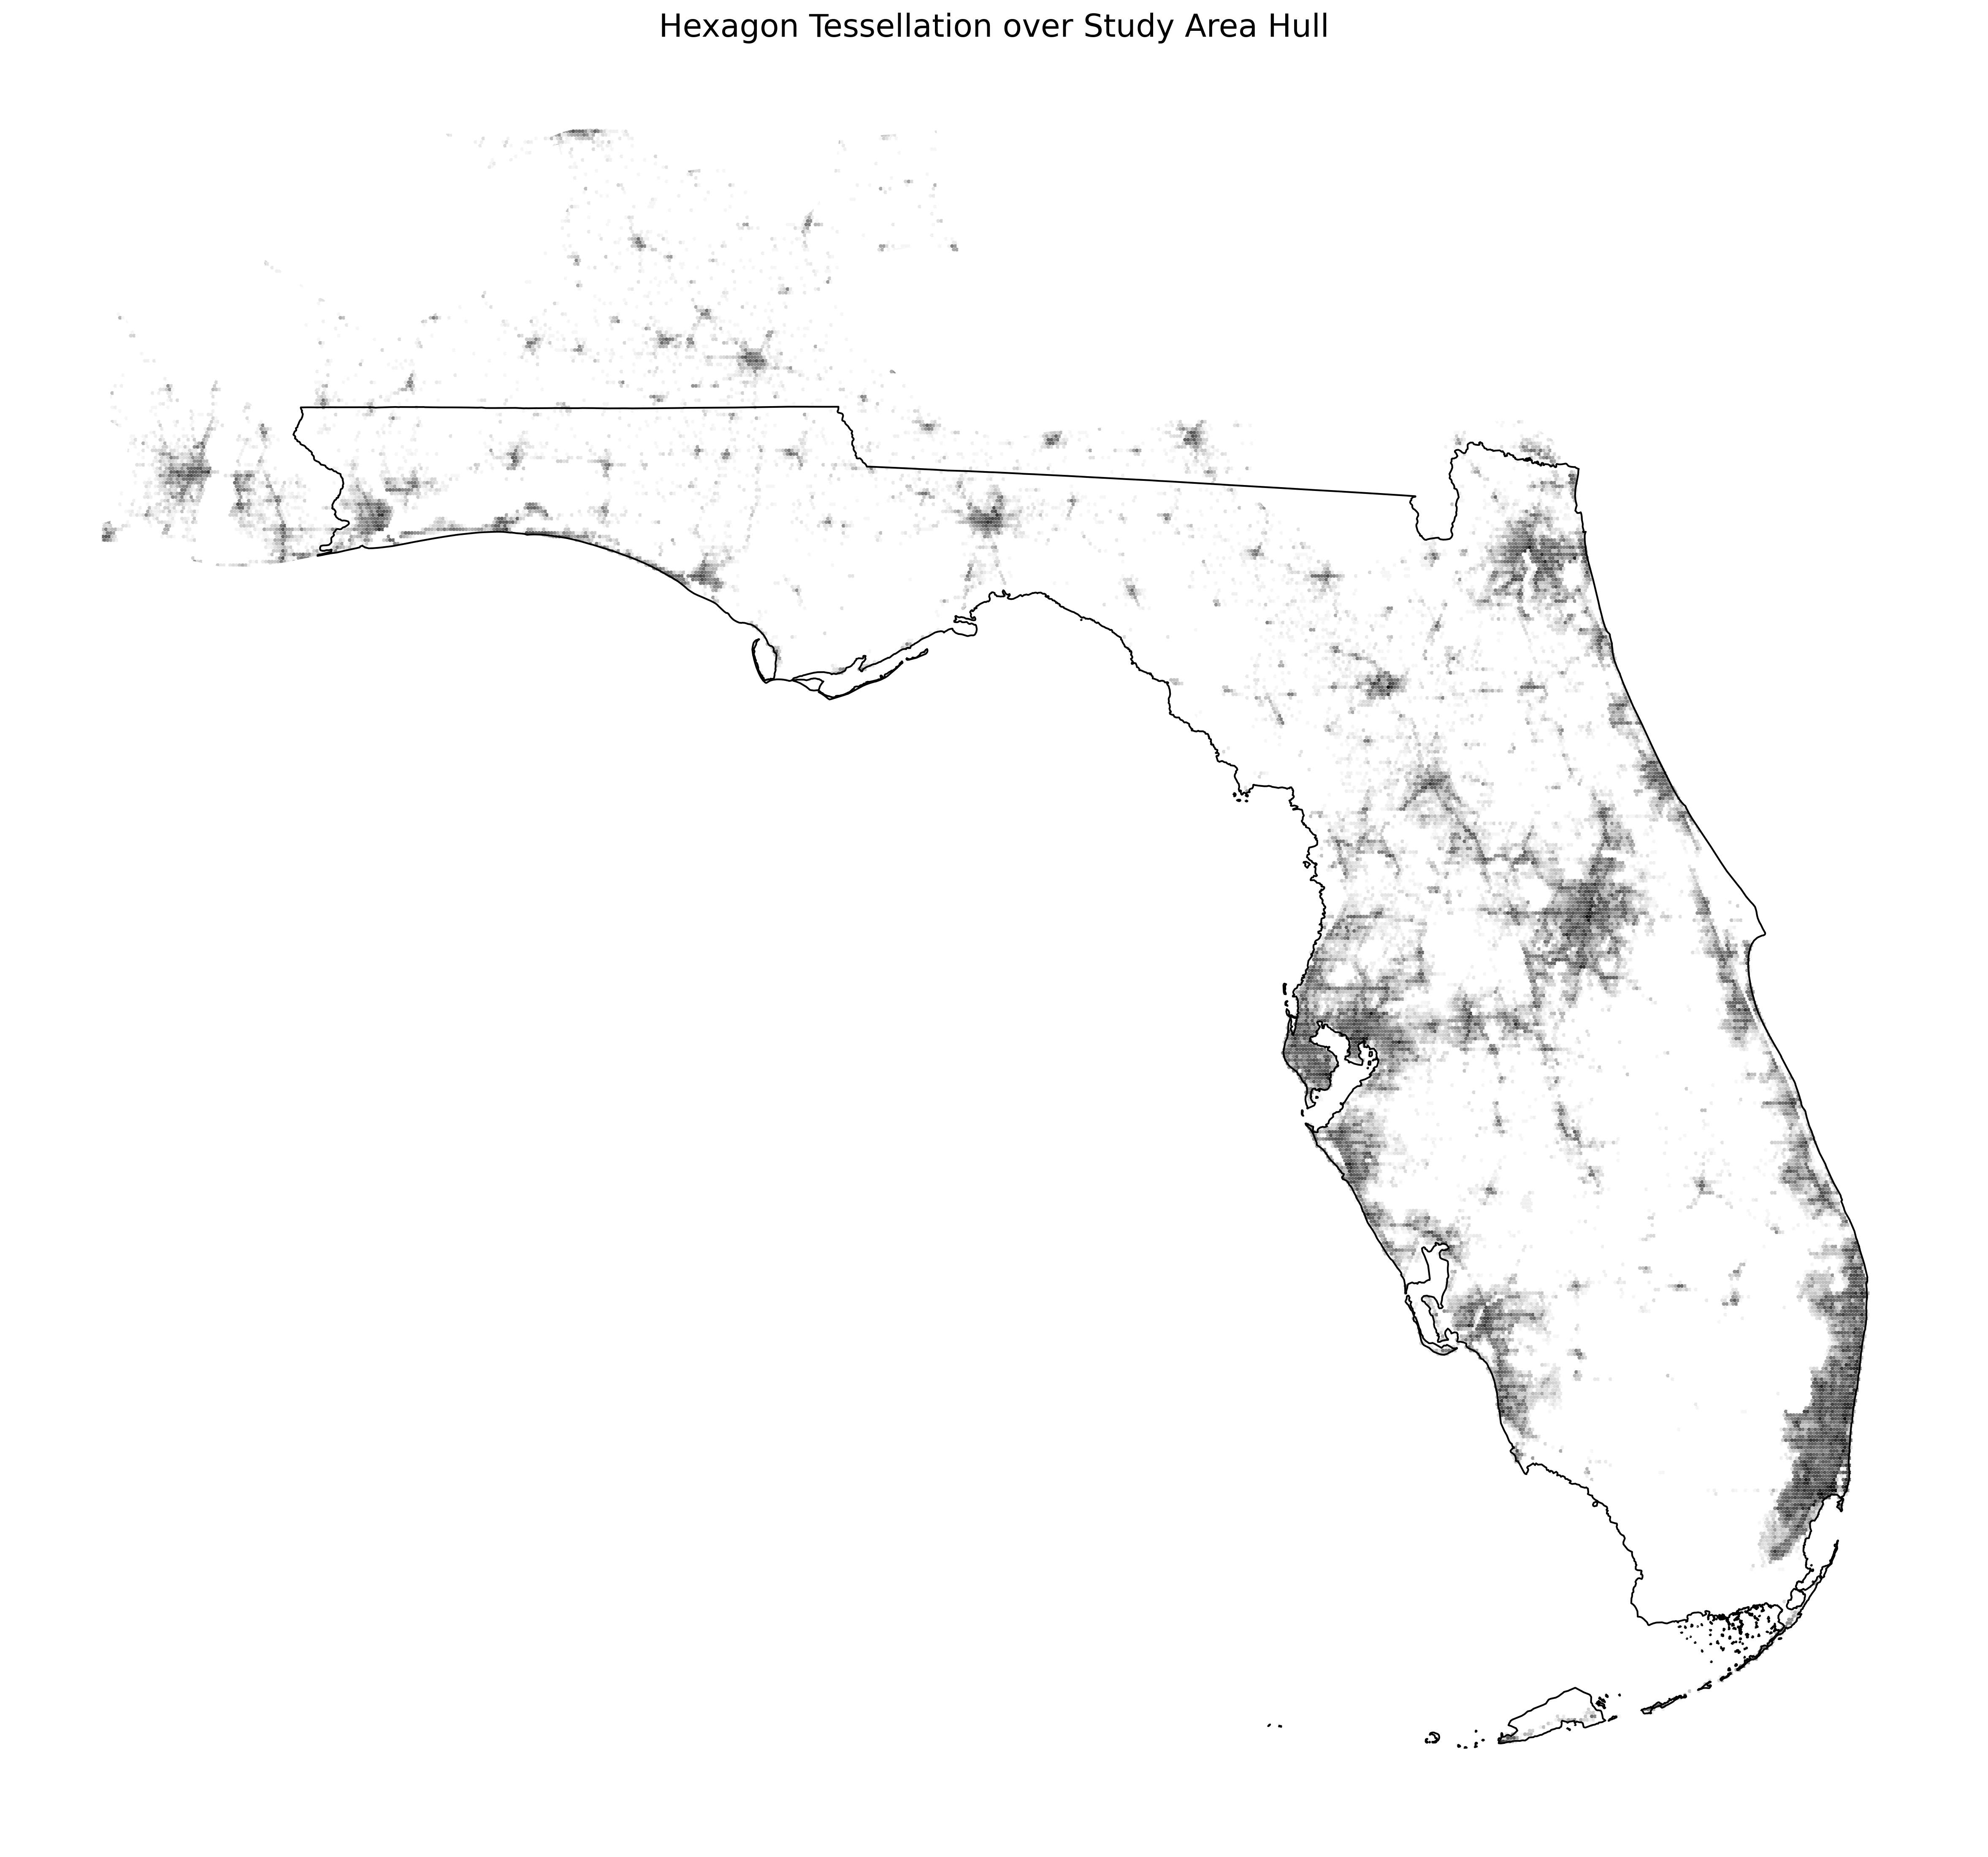

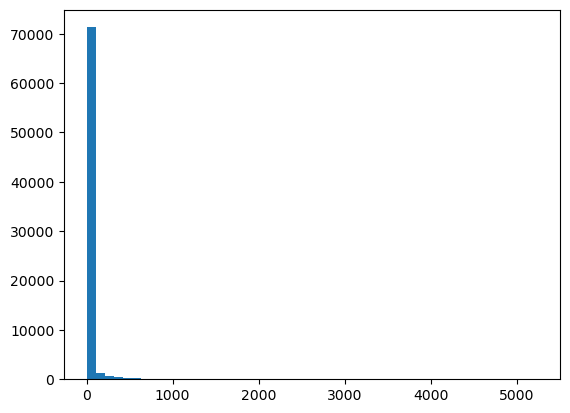

max: 5237 95%: 92.0 99%: 490.5


In [202]:
import matplotlib.colors as colors

import matplotlib
def count_log_pois(poi_list: list) -> int:
    """
    Returns:
      • 0, if poi_list == ["<null_val>[sep]<null_val>[sep]<null_val>"]
      • len(poi_list), otherwise.
    """
    if len(poi_list) == 1 and poi_list[0] == "<null_val>[sep]<null_val>[sep]<null_val>":
        return 1e-6
    return np.log(len(poi_list))

def count_pois(poi_list: list) -> int:
    """
    Returns:
      • 0, if poi_list == ["<null_val>[sep]<null_val>[sep]<null_val>"]
      • len(poi_list), otherwise.
    """
    if len(poi_list) == 1 and poi_list[0] == "<null_val>[sep]<null_val>[sep]<null_val>":
        return 0
    return len(poi_list)
# Apply to create a new column “num_pois”
new_gdf["log_num_pois"] = new_gdf["concatenated"].apply(count_log_pois)
new_gdf["num_pois"] = new_gdf["concatenated"].apply(count_pois)
print(new_gdf["num_pois"].sum())
print(new_gdf)
fig, ax = plt.subplots(figsize=(20, 20), dpi=300)
new_gdf = gpd.GeoDataFrame(new_gdf, geometry="geometry")
# Plot the hull boundary
#hull_gdf.boundary.plot(ax=ax, color='black', linewidth=1)
states[states.STUSPS=="FL"].boundary.plot(ax=ax, color='black', linewidth=1)
# Plot all hexagon boundaries
#hex_gdf.boundary.plot(ax=ax, edgecolor='gray', linewidth=0.3)
new_gdf.plot(ax=ax,column="log_num_pois", cmap='Greys', linewidth=0.3 ,)
# Optional: fill the hull lightly for context
#hull_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

ax.set_aspect('equal')
ax.set_axis_off()
plt.title("Hexagon Tessellation over Study Area Hull", fontsize=18)
plt.show()
plt.hist(new_gdf["num_pois"],bins=50)
plt.show()
print(f"max: {max(new_gdf["num_pois"])} 95%: {new_gdf["num_pois"].quantile(0.95)} 99%: {new_gdf["num_pois"].quantile(0.99)}")

In [29]:
print(point_gdf.crs)
new_gdf = new_gdf.set_crs(point_gdf.crs)
new_gdf = new_gdf.rename(columns={"index": "hex_id"})
print(new_gdf.crs)

EPSG:4326
EPSG:4326


In [31]:
clean_joined = joined_nearest.drop_duplicates(subset=["traj_id", "pt_idx"])
clean_joined.crs

print(clean_joined)

                                                   traj_id  pt_idx  \
0        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       1   
1        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       3   
2        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       5   
3        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      20   
4        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...      21   
...                                                    ...     ...   
1677305  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     130   
1677306  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     133   
1677307  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     134   
1677308  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     140   
1677309  559f9e9acaaf7e32ea1c7b2616af890a63a5fd8ebd2a54...     141   

                           geometry hex_id  \
0        POINT (-81.79671 24.54831)     48   
1        POINT (-81.79674 24.54832)     48   
2        POINT (-81.7

In [203]:
counts_hex_gdf = hex_gdf.copy()
counts_hex_gdf = counts_hex_gdf.set_index("hex_id", drop=False)
point_counts = clean_joined.groupby("hex_id").size()
point_counts = point_counts.rename("traj_count").to_frame()
print(point_counts)
counts_hex_gdf = counts_hex_gdf.join(point_counts, how="left")

# 2.3: Fill NaN with 0 for hexes that had no points
counts_hex_gdf["traj_count"] = counts_hex_gdf["traj_count"].fillna(0).astype(int)
print(counts_hex_gdf["traj_count"].sum())

        traj_count
hex_id            
0                1
10006            1
10023            2
10054            1
10055            1
...            ...
9966            20
9974             2
9982             1
9997             4
9998            39

[13459 rows x 1 columns]
1677310


In [204]:
import random

all_ids = clean_joined["traj_id"].unique()
# Shuffle in place (or you can pick the first N deterministically)
random.shuffle(all_ids)

# Let’s plot 3 trajectories:
sample_ids = all_ids[:10]
print("Plotting trajectories for traj_id =", sample_ids[1])

Plotting trajectories for traj_id = bac45fccaacbc400daa63e6ebf8c9b6e569d3eecf0202182da58f846ca45c20a


In [205]:
import matplotlib as mpl

# ────────────────────────────────────────────────────────────────────────────────
# Assume `hex_gdf` already has a column "traj_count" (integer ≥ 0).

# (1) Replace zeros with a small positive value (e.g. 1) so LogNorm can handle them.
#     All hexes that originally had traj_count=0 will appear at the bottom‐most color.
counts_hex_gdf["traj_count_for_log"] = counts_hex_gdf["traj_count"].replace(0, 1).astype(float)

# (2) Create the LogNorm object. 
#     vmin must be ≥ 1 (since we replaced zeros with 1). vmax is the maximum count.
vmin = 1
vmax = counts_hex_gdf["traj_count_for_log"].max()
log_norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)

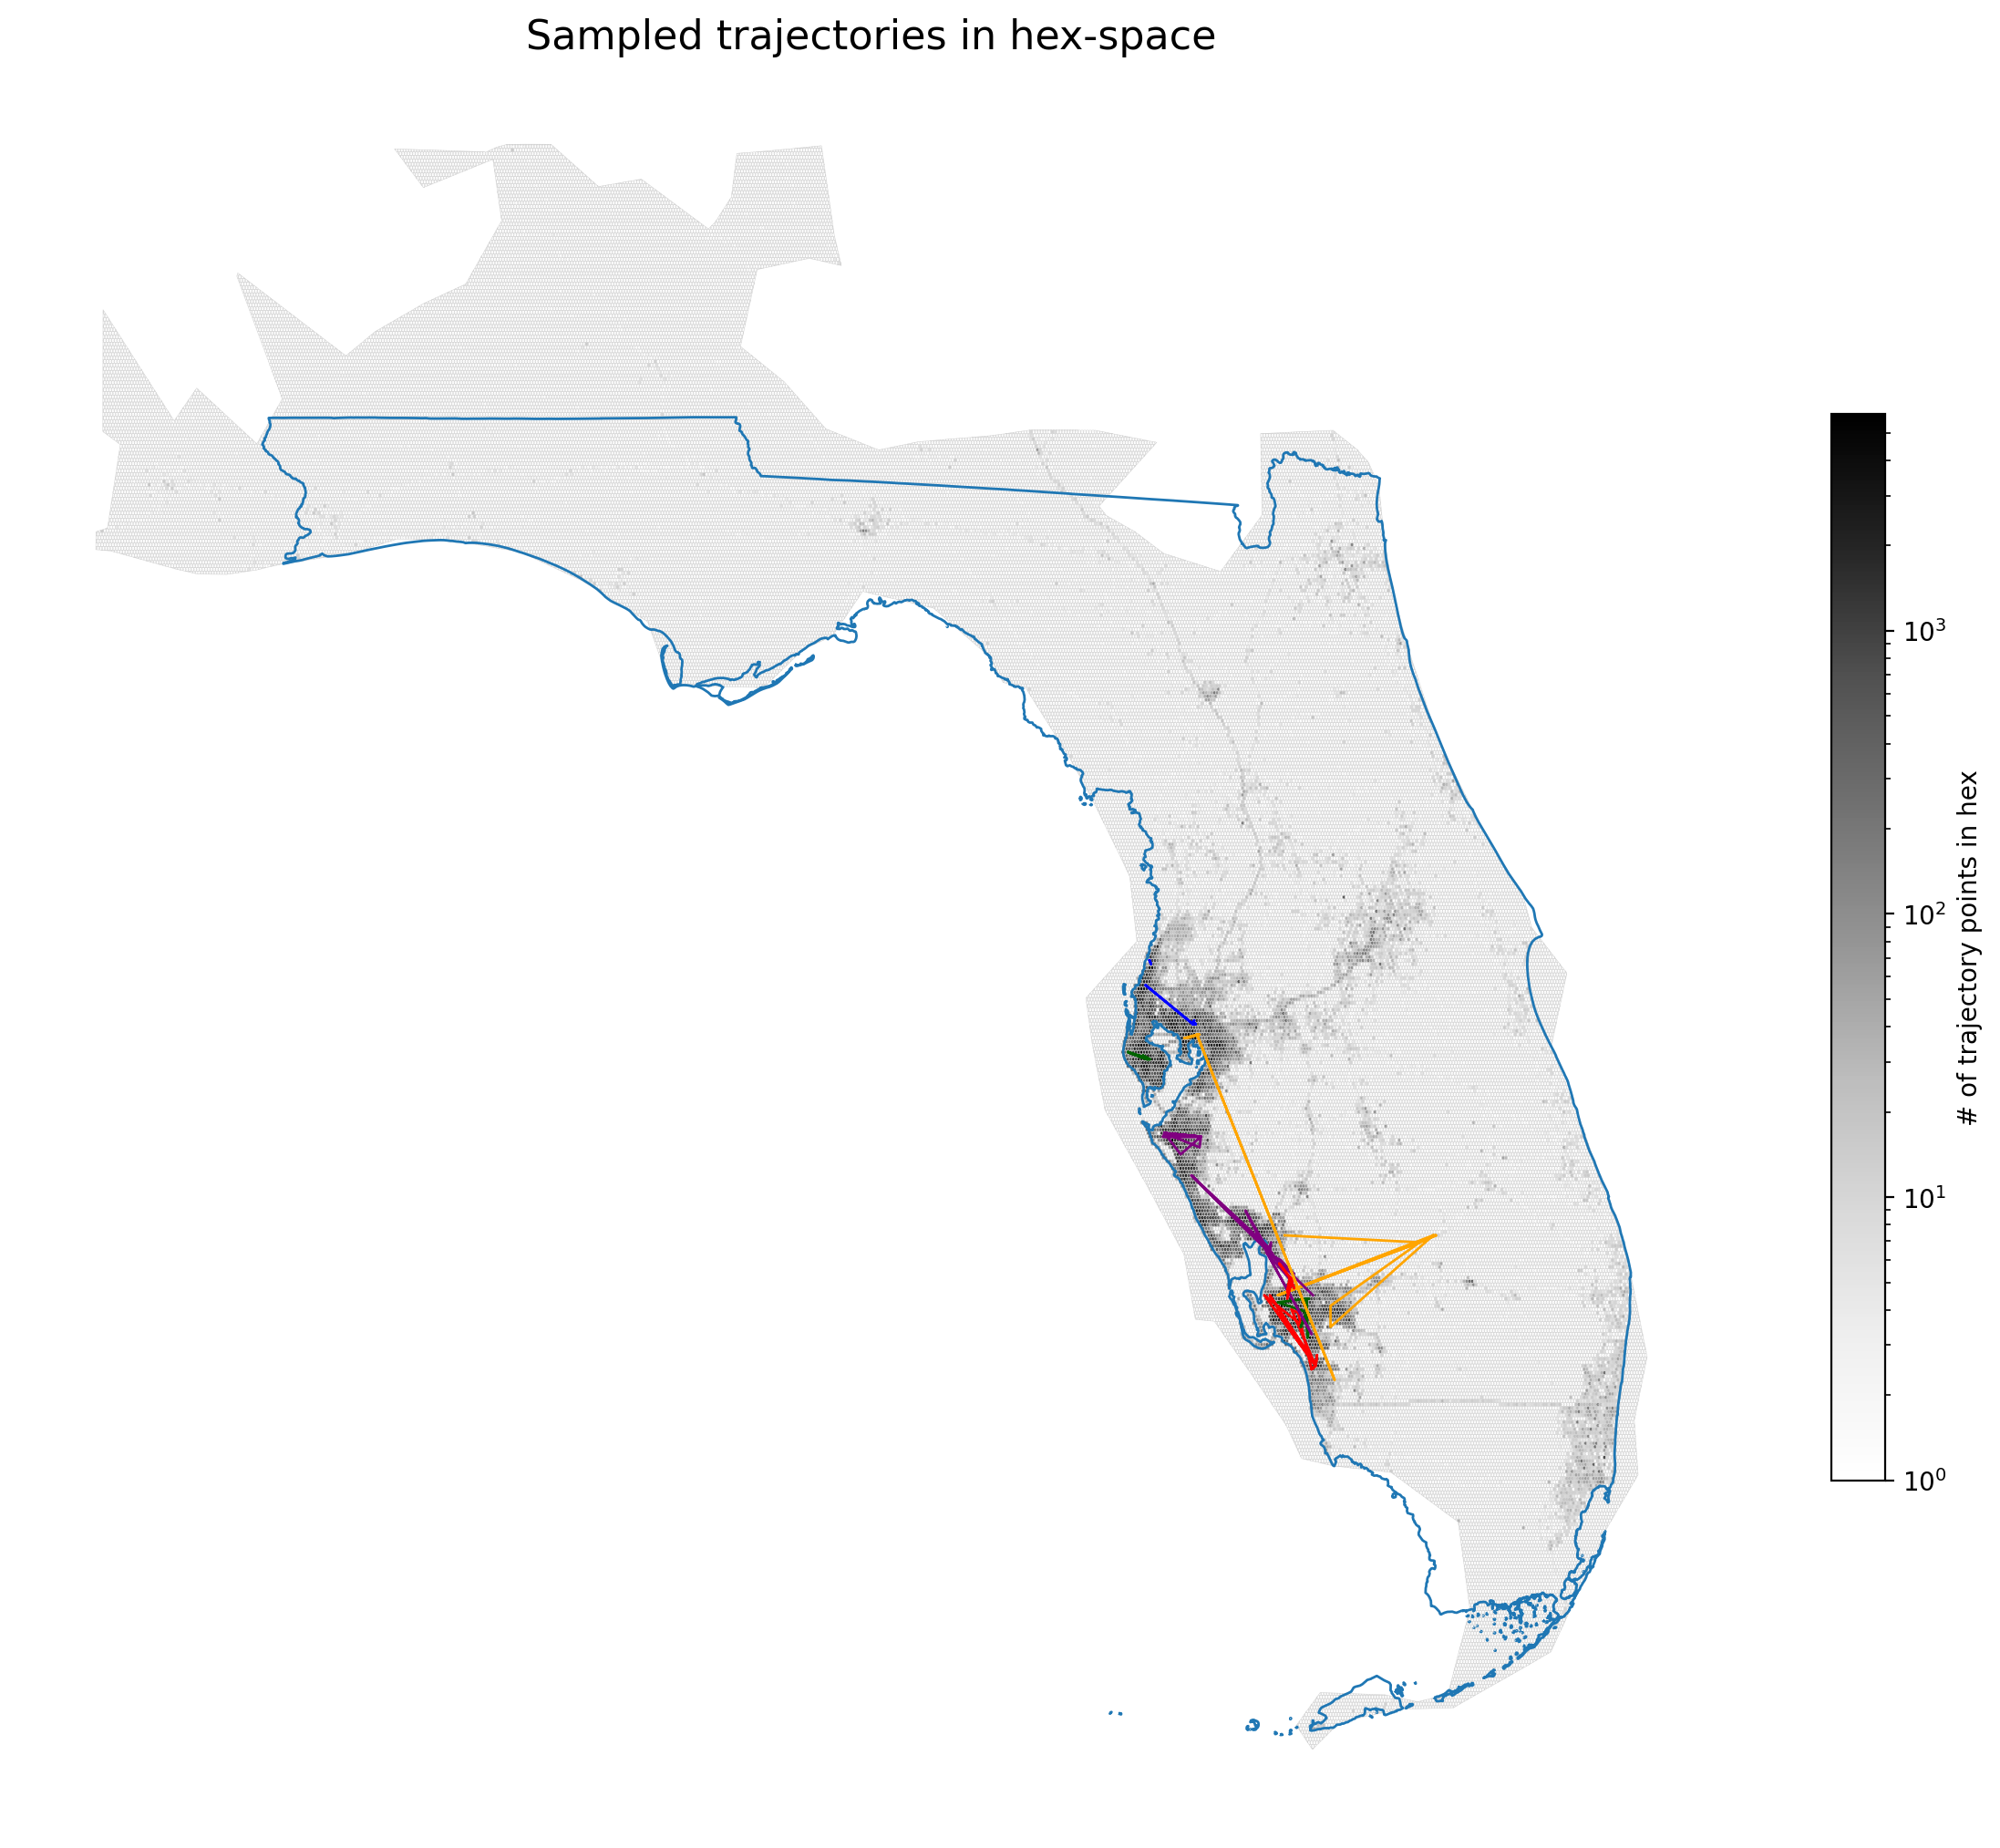

In [206]:
from shapely.geometry import LineString
joined = clean_joined.copy()
# 3) Reconstruct each sampled trajectory as a LineString of centroids:
traj_lines = []
for tid in sample_ids:
    sub = joined[joined["traj_id"] == tid ].sort_values("pt_idx")
    hex_sequence = sub["hex_id"].tolist()
    centroids = []
    for h in hex_sequence:
        if pd.isna(h):
            continue
        cent = hex_gdf.loc[int(h), "centroid"]
        centroids.append(cent)
    if len(centroids) >= 2:
        traj_lines.append({
            "traj_id": tid,
            "geometry": LineString(centroids)
        })

traj_lines_gdf = gpd.GeoDataFrame(traj_lines, geometry="geometry", crs=hex_gdf.crs)

# 4) Plot the hex grid and the sampled hex‐trajectories:
fig, ax = plt.subplots(figsize=(12, 12), dpi=200)
counts_hex_gdf.plot(
    column="traj_count",            # use this column to drive the fill color
    cmap="Greys",                 # or any other matplotlib colormap
    linewidth=0.2, 
    norm=log_norm, # thin border around hexes
    edgecolor="lightgray",          
    legend=True,                    # draw colorbar
    legend_kwds={
        "label": "# of trajectory points in hex",
        "shrink": 0.5
    },
    ax=ax
)
states[states.STUSPS=="FL"].boundary.plot(ax=ax, linewidth=1)
colors = ["red", "blue", "darkgreen", "orange", "purple"]
for i, row in traj_lines_gdf.iterrows():
    line = row.geometry
    tid = row.traj_id
    c = colors[i % len(colors)]
    ax.plot(*line.xy, color=c, linewidth=1, label=f"{tid[:6]}…")

ax.set_title("Sampled trajectories in hex‐space", fontsize=16)
ax.set_axis_off()
#ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig("sample_traj_hex.png")
plt.show()


In [37]:
from node2vec import Node2Vec
from gensim.models import Word2Vec

#node2vec = Node2Vec(G, dimensions=128, walk_length=128, num_walks=128, workers=8)  # Use temp_folder for big graphs

In [38]:
#model = node2vec.fit(vector_size=128, window=16, min_count=1, workers=8, batch_words=256)  # Any keywords acceptable by gensim.Word2Vec can be passed, `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)

In [39]:
EMBEDDING_FILENAME = "models/word2vec_embeddings.emb"
EMBEDDING_MODEL_FILENAME = "models/word2vec_embeddings.model"


In [40]:
#model.wv.save_word2vec_format(EMBEDDING_FILENAME)

# Save model for later use
#model.save(EMBEDDING_MODEL_FILENAME)

In [41]:
from gensim.models import Word2Vec
# Load model after Node2Vec.save
vec_model = Word2Vec.load(EMBEDDING_MODEL_FILENAME)

# Load model after Node2Vec.wv.save_word2vec_format
#model = Word2Vec.load_word2vec_format(EMBEDDING_FILENAME)

2025-06-11 15:20:45,651 - INFO - utils.py:481 - loading Word2Vec object from models/word2vec_embeddings.model
2025-06-11 15:20:45,770 - INFO - utils.py:515 - loading wv recursively from models/word2vec_embeddings.model.wv.* with mmap=None
2025-06-11 15:20:45,771 - INFO - utils.py:553 - setting ignored attribute cum_table to None
2025-06-11 15:20:46,182 - INFO - utils.py:447 - Word2Vec lifecycle event {'fname': 'models/word2vec_embeddings.model', 'datetime': '2025-06-11T15:20:46.182820', 'gensim': '4.3.3', 'python': '3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]', 'platform': 'Linux-4.18.0-477.27.1.el8_8.x86_64-x86_64-with-glibc2.35', 'event': 'loaded'}


In [42]:
embeddings = {node: vec_model.wv[node] for node in G.nodes()}
emb_dataframe = pd.DataFrame.from_dict(embeddings)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
# 4) Move to GPU/CPU and set eval mode:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 1) Where you saved your LoRA adapters after training:
CHECKPOINT = "/storage1/fs1/nlin/Active/sizhe/FO_DATA/checkpoint-dir/checkpoint-551"

# 2) Load the tokenizer from that folder (it contains tokenizer.json + vocab.txt)
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

base_name = "google/gemma-3-1b-it"     # <— exactly what you passed in your training script
base = AutoModelForCausalLM.from_pretrained(
    "google/gemma-3-1b-it",
    attn_implementation="eager"
).to(device)

# 3) Now graft the adapter weights:
model = PeftModel.from_pretrained(base, CHECKPOINT)


model.to(device).eval()



In [86]:
def embed_texts(texts: list[str]) -> torch.Tensor:
    """
    texts: a Python list of strings (each may contain literal "[sep]").
    example: ["[Museums, Historical Sites,...<sep>Museums, Historical Sites<sep>Natural History museum]",...]
    In the format of [<category><sep><subcategory><sep><name>]
    Returns: a GPU tensor of shape (len(texts), hidden_size) containing the
             final‐token embedding for each string.
    """
    # 2.1) Clean & force everything to str, replacing None/NaN with ""
    clean_texts=[]
    for t in texts:
        if t is None:
            clean_texts.append("")
        else:
            clean_texts.append(str(t))
    sep = tokenizer.sep_token  # e.g. "[SEP]" for BERT‐style; whatever your tokenizer.sep_token is
    clean_texts = [t.replace("[sep]", sep) for t in clean_texts]
    
    # 2.3) Batch‐tokenize all strings onto GPU
    enc = tokenizer(
        clean_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
        return_token_type_ids=False,
    ).to(device)
    #print("Batch input_ids are on:", enc.input_ids.device)
    # Now enc.input_ids and enc.attention_mask live on GPU.

    # 2.4) Forward‐pass (no gradients) to get hidden states
    with torch.no_grad():
        outputs = model.base_model(
            input_ids=enc.input_ids,
            attention_mask=enc.attention_mask,
            output_hidden_states=True
        )
        # `outputs.hidden_states` is a tuple of length (num_layers+1);
        # each element has shape (batch_size, seq_len, hidden_size).
        last_hidden = outputs.hidden_states[-1]  # (batch_size, seq_len, hidden_size) on GPU

    # 2.5) For each sequence, pick out the final non‐pad token embedding
    seq_lens = enc.attention_mask.sum(dim=1) - 1  # (batch_size,) on GPU, index of last non-pad
    batch_size, hidden_size = last_hidden.size(0), last_hidden.size(2)

    # Gather the embedding at position (i, seq_lens[i], :)
    final_embs = last_hidden[torch.arange(batch_size), seq_lens, :]  # (batch_size, hidden_size) on GPU
    #print((final_embs))
    return final_embs


In [45]:
import transformers, sys
print("Python executable:", sys.executable)
print("Transformers version:", transformers.__version__)
print("Transformers path:   ", transformers.__file__)


Python executable: /storage1/fs1/nlin/Active/sizhe/sizhe/envs/geospatial/bin/python
Transformers version: 4.52.4
Transformers path:    /storage1/fs1/nlin/Active/sizhe/sizhe/envs/geospatial/lib/python3.12/site-packages/transformers/__init__.py


In [120]:
Hull_FL_POI_GDF

,Unnamed: 0.1,index,Unnamed: 0,PLACEKEY,LONGITUDE,LATITUDE,concatenated,REGION,LOCATION_NAME,geometry,concatenated_vec
0,0,0,4,zzy-22s@8dj-jv6-ks5,-82.524818,27.949076,Activities Related to Real Estate[sep]Resident...,FL,Jeffrey Berg,POINT (-82.524818 27.949076),"[-3.4153352, -1.4993178, 1.3645281, -0.1515835..."
1,1,1,6,zzy-22s@8gp-3nn-3dv,-81.380769,30.199156,Offices of Real Estate Agents and Brokers[sep]...,FL,Search Beacon Realty,POINT (-81.380769 30.199156),"[-2.3808935, 2.1814017, -0.8132436, -1.7732259..."
2,2,2,12,zzy-22t@8dh-h4q-gx5,-81.769293,24.566605,"Sporting Goods, Hobby, and Musical Instrument ...",FL,Bone Island Music Key West,POINT (-81.769293 24.566605),"[0.5421089, 1.6325231, -0.19950798, 0.62199396..."
3,3,3,27,zzy-234@8gp-2dc-fj9,-81.682551,30.203123,Offices of Dentists[sep]Offices of Dentists[se...,FL,Dr. Arbel Maghsoodpour DDS,POINT (-81.682551 30.203123),"[-3.0437524, -1.1710362, 0.6872603, 1.9748062,..."
4,4,4,157,zzz-222@8dg-kpy-btv,-81.847107,26.642022,"Museums, Historical Sites, and Similar Institu...",FL,Roberto Clemente Park,POINT (-81.847107 26.642022),"[2.6489968, 0.4961787, -0.9975236, 0.6901425, ..."
...,...,...,...,...,...,...,...,...,...,...,...
1548012,1548012,1642499,20309583,zzy-222@8gq-r2j-t5f,-81.426410,29.784013,Home Furnishings Stores[sep]All Other Home Fur...,FL,FL Custom Kitchen and Baths,POINT (-81.42641 29.784013),"[5.1950994, -3.5654666, 1.3610862, 4.8711176, ..."
1548013,1548013,1642500,20309584,zzy-222@8gq-tkh-qcq,-81.070241,29.217953,Urban Transit Systems[sep]Bus and Other Motor ...,FL,Votran Cedar Highlands & Jimmy Ann Ib,POINT (-81.070241 29.217953),"[2.0651934, -2.151216, 0.12744871, -1.3617337,..."
1548014,1548014,1642501,20309585,zzy-222@8gq-tsg-5vf,-81.322792,29.042548,Urban Transit Systems[sep]Bus and Other Motor ...,FL,Votran Plymouth & 15a Ib,POINT (-81.322792 29.042548),"[2.2203841, -0.89032716, 0.44813, -0.57312757,..."
1548015,1548015,1642502,20309586,zzy-222@8gq-wfw-yd9,-81.019375,29.249829,Urban Transit Systems[sep]Bus and Other Motor ...,FL,Votran Zelda & A1a Ib,POINT (-81.019375 29.249829),"[0.76949054, -0.3188232, 3.1625767, -0.9362155..."


In [47]:
print("special_tokens_map:", tokenizer.special_tokens_map)


special_tokens_map: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]', 'additional_special_tokens': ['<null_val>']}


In [107]:
from tqdm.auto import tqdm
import torch
import os

np.set_printoptions(threshold=sys.maxsize)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
all_texts = Hull_FL_POI_GDF["concatenated"].tolist()
N = len(all_texts)
BATCH_SIZE = 256

cpu_chunks: list[torch.Tensor] = []

print(f"Embedding {N} rows in batches of {BATCH_SIZE}…")
for i in tqdm(range(0, N, BATCH_SIZE), desc="Batches"):
    batch_texts = all_texts[i : i + BATCH_SIZE]
    batch_embs_gpu = embed_texts(batch_texts)         # (batch_size, H) on GPU

    # 1️⃣ move immediately to CPU and free GPU memory
    batch_embs_cpu = batch_embs_gpu.cpu()
    if i%1000000 == 0:
        #print(batch_embs_cpu.numpy())
        print(f"Length is {len(batch_embs_cpu.numpy()[0])}")
    cpu_chunks.append(batch_embs_cpu)
    
    del batch_embs_gpu
    torch.cuda.empty_cache()

# 2️⃣ concatenate on CPU only
full_cpu_tensor = torch.cat(cpu_chunks, dim=0)         # (N, H) on CPU
full_cpu_numpy  = full_cpu_tensor.numpy()

Hull_FL_POI_GDF["concatenated_vec"] = list(full_cpu_numpy)
Hull_FL_POI_GDF.to_csv("Hull_FL_poi_vec_subset.csv")
print("✅ Done. Never held a full (N, H) tensor on GPU.")


Embedding 1548017 rows in batches of 256…


Batches:   0%|          | 0/6047 [00:00<?, ?it/s]

Length is 1152
✅ Done. Never held a full (N, H) tensor on GPU.


In [211]:
from shapely import wkt

#Hull_FL_POI_GDF=pd.read_csv("Hull_FL_poi_vec_subset.csv")

buffer_Hull_FL_POI_GDF=Hull_FL_POI_GDF.copy()
try:
    buffer_Hull_FL_POI_GDF['geometry'] = buffer_Hull_FL_POI_GDF['geometry'].apply(wkt.loads)
except Exception as e:
    print(e)
    
#buffer_Hull_FL_POI_GDF["geometry"] = Hull_FL_POI_GDF.geometry.buffer(1e-3)
buffer_Hull_FL_POI_GDF = gpd.GeoDataFrame(buffer_Hull_FL_POI_GDF, geometry = "geometry", crs = hex_gdf.crs)
buffer_Hull_FL_POI_GDF  = buffer_Hull_FL_POI_GDF.to_crs(epsg=5070)
hex_buffer = hex_gdf.to_crs(epsg=5070)
joined_ll = gpd.sjoin_nearest(
    buffer_Hull_FL_POI_GDF[["concatenated_vec", "geometry"]],  # keep only the columns we care about
    hex_buffer[["hex_id","geometry","centroid"]],  
    how="left",           # keep all points; hex attributes will be NaN if a point is unmatched
)
#joined = joined.drop_duplicates(subset=["hex_id"])
joined = joined_ll.to_crs(epsg=4326)
# joined now has one row per point, with hex columns appended (e.g. “hex_id” from hex_gdf)
print(joined.head(10))
print("Total points:", len(buffer_Hull_FL_POI_GDF))
print("Matched points:", joined["hex_id"].notna().sum())
print("Unmatched points:", joined["concatenated_vec"].isna().sum())

# If many points remain unmatched (isna), it means they truly fall outside all hex polygons.


# ── (6) If you only want the points that *did* join to a hex, then:
matched_points = joined[joined["hex_id"].notna()]

# If you want one row per hex_id, you can now aggregate matched_points by hex_id:
# e.g. if each matched_point has a “hex_id” column (copied from hex_gdf index):
hex_counts = (
    matched_points
    .groupby("hex_id")    # or “index_hex” if you used index-based join
    .size()
    .rename("poi_count")
    .reset_index()
)

# 2. Set "hex_id" (or "concatenated_hex_id") as the new index
matched_points = matched_points.set_index("hex_id")
#matched_points = matched_points.drop(columns="index_left")

Expected bytes or string, got Point
                                    concatenated_vec                    geometry  index_right hex_id                   centroid
0  [-3.4153352, -1.4993178, 1.3645281, -0.1515835...  POINT (-82.52482 27.94908)        23059  23059   POINT (-82.525 27.94916)
1  [-2.3808935, 2.1814017, -0.8132436, -1.7732259...  POINT (-81.38077 30.19916)        45558  45558   POINT (-81.385 30.20083)
2  [0.5421089, 1.6325231, -0.19950798, 0.62199396...   POINT (-81.76929 24.5666)           64     64  POINT (-81.7675 24.57166)
3  [-3.0437524, -1.1710362, 0.6872603, 1.9748062,...  POINT (-81.68255 30.20312)        45538  45538   POINT (-81.685 30.20083)
4  [2.6489968, 0.4961787, -0.9975236, 0.6901425, ...  POINT (-81.84711 26.64202)        10279  10279  POINT (-81.8425 26.65012)
5  [3.9368472, -3.052388, 1.2083341, 1.7413621, -...  POINT (-82.09848 28.02386)        23779  23779   POINT (-82.105 28.01844)
6  [-0.86371475, -0.14614065, 1.00268, -0.3367607...  POINT (-80.232

In [214]:
len(joined["index_right"].unique())

25661

em

In [157]:
print(hex_gdf)
print(point_gdf)

                                                geometry hex_id                    centroid  centroid_x  centroid_y                                           vec_mean
0      POLYGON ((-81.8 24.45908, -81.79741 24.4546, -...      0  POINT (-81.80131 24.45615)  -81.801311   24.456155                                                NaN
1      POLYGON ((-81.795 24.45908, -81.79236 24.45908...      1  POINT (-81.79504 24.45748)  -81.795042   24.457484                                                NaN
2      POLYGON ((-81.8175 24.4764, -81.8075 24.4764, ...      2  POINT (-81.80955 24.47009)  -81.809554   24.470090                                                NaN
3      POLYGON ((-81.7925 24.45908, -81.8025 24.45908...      3   POINT (-81.7975 24.46774)  -81.797500   24.467741                                                NaN
4      POLYGON ((-81.7925 24.46774, -81.7875 24.4764,...      4  POINT (-81.78502 24.47073)  -81.785019   24.470731                                                Na

In [215]:
mean_vecs = (
    joined
    .groupby('hex_id')['concatenated_vec']
    .agg(lambda arrs: np.mean(np.stack(arrs.values), axis=0))
)
# mean_vecs is a Series: index=hex_id, value=np.ndarray(1152,)

# 2a) merge into hex_gdf
hex_gdf = hex_gdf.merge(
    mean_vecs.rename('vec_mean'),
    left_on='hex_id',
    right_index=True,
    how='left'
)

In [216]:
null_emb = (
    embed_texts(["<null_val>[sep]<null_val>[sep]<null_val>"])
      .cpu()
      .numpy()[0]
)

In [217]:
def fill_vec(x):
    # detect the NaN (it's a float)
    if isinstance(x, float) and pd.isna(x):
        return null_emb
    else:
        return x

hex_gdf['vec_mean'] = hex_gdf['vec_mean'].apply(fill_vec)

In [218]:
hex_gdf.head

<bound method NDFrame.head of                                                 geometry hex_id                    centroid  centroid_x  centroid_y                                           vec_mean
0      POLYGON ((-81.8 24.45908, -81.79741 24.4546, -...      0  POINT (-81.80131 24.45615)  -81.801311   24.456155  [2.5867763, -5.514072, 0.21381025, -1.8397896,...
1      POLYGON ((-81.795 24.45908, -81.79236 24.45908...      1  POINT (-81.79504 24.45748)  -81.795042   24.457484  [2.5867763, -5.514072, 0.21381025, -1.8397896,...
2      POLYGON ((-81.8175 24.4764, -81.8075 24.4764, ...      2  POINT (-81.80955 24.47009)  -81.809553   24.470090  [2.5867763, -5.514072, 0.21381025, -1.8397896,...
3      POLYGON ((-81.7925 24.45908, -81.8025 24.45908...      3   POINT (-81.7975 24.46774)  -81.797500   24.467741  [2.5867763, -5.514072, 0.21381025, -1.8397896,...
4      POLYGON ((-81.7925 24.46774, -81.7875 24.4764,...      4  POINT (-81.78502 24.47073)  -81.785019   24.470732  [2.5867763, -5.514

In [219]:
vecs = emb_dataframe.to_numpy().T   # shape (N, D)

# 2) turn each row into a Python list
vec_lists = vecs.tolist()           # [ [float,…,float], … ]

# 3) assign by position (assuming hex_gdf is already sorted by hex_id 0…N-1)
hex_gdf['embedding'] = vec_lists

In [220]:
hex_gdf

,geometry,hex_id,centroid,centroid_x,centroid_y,vec_mean,embedding
0,"POLYGON ((-81.8 24.45908, -81.79741 24.4546, -...",0,POINT (-81.80131 24.45615),-81.801311,24.456155,"[2.5867763, -5.514072, 0.21381025, -1.8397896,...","[0.09606605768203735, 0.07447724789381027, -0...."
1,"POLYGON ((-81.795 24.45908, -81.79236 24.45908...",1,POINT (-81.79504 24.45748),-81.795042,24.457484,"[2.5867763, -5.514072, 0.21381025, -1.8397896,...","[0.07220429927110672, 0.1220816895365715, -0.7..."
2,"POLYGON ((-81.8175 24.4764, -81.8075 24.4764, ...",2,POINT (-81.80955 24.47009),-81.809553,24.470090,"[2.5867763, -5.514072, 0.21381025, -1.8397896,...","[-0.01806499809026718, 0.036709435284137726, -..."
3,"POLYGON ((-81.7925 24.45908, -81.8025 24.45908...",3,POINT (-81.7975 24.46774),-81.797500,24.467741,"[2.5867763, -5.514072, 0.21381025, -1.8397896,...","[0.01906248927116394, 0.13962283730506897, -0...."
4,"POLYGON ((-81.7925 24.46774, -81.7875 24.4764,...",4,POINT (-81.78502 24.47073),-81.785019,24.470732,"[2.5867763, -5.514072, 0.21381025, -1.8397896,...","[-0.021365929394960403, 0.2040795385837555, -0..."
...,...,...,...,...,...,...,...
74746,"POLYGON ((-86.09 32.33991, -86.1 32.33991, -86...",74746,POINT (-86.09502 32.34136),-86.095023,32.341364,"[2.9250407, -3.7403543, -0.38289627, 0.3976613...","[-0.06934382021427155, 0.6404999494552612, -0...."
74747,"POLYGON ((-86.075 32.33991, -86.085 32.33991, ...",74747,POINT (-86.08002 32.34133),-86.080023,32.341332,"[1.0132802, 0.79524815, 0.88847315, 0.48499015...","[0.024670490995049477, 0.6511200070381165, -0...."
74748,"POLYGON ((-86.06 32.33991, -86.07 32.33991, -8...",74748,POINT (-86.06502 32.3413),-86.065023,32.341301,"[-0.9133049, -0.3142788, 1.2036457, -0.7082768...","[0.11119662970304489, 0.5814794898033142, -0.2..."
74749,"POLYGON ((-86.045 32.33991, -86.055 32.33991, ...",74749,POINT (-86.05002 32.34127),-86.050023,32.341270,"[2.5867763, -5.514072, 0.21381025, -1.8397896,...","[0.21319125592708588, 0.5063827037811279, -0.2..."


In [222]:
point_buffer = point_gdf.to_crs(epsg=5070)
hex_gdf_buffer = hex_gdf.to_crs(epsg=5070)


joined_nearest_ll = gpd.sjoin_nearest(
    point_buffer[["traj_id", "pt_idx", "geometry"]],  # keep only the columns we care about
    hex_gdf_buffer[["geometry","vec_mean","embedding","centroid"]],  
    how="left"           # keep all points; hex attributes will be NaN if a point is unmatche
)
joined_nearest = joined_nearest_ll.to_crs(epsg=4326)
print(joined_nearest)

                                                   traj_id  pt_idx                    geometry  index_right                                           vec_mean                                          embedding                   centroid
0        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       1  POINT (-81.79671 24.54831)           48  [0.53333396, -0.6309159, 0.4254715, -0.6440962...  [-0.6102308034896851, -0.023300886154174805, -...    POINT (-81.79 24.55434)
1        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       3  POINT (-81.79674 24.54832)           48  [0.53333396, -0.6309159, 0.4254715, -0.6440962...  [-0.6102308034896851, -0.023300886154174805, -...    POINT (-81.79 24.55434)
2        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       5  POINT (-81.79665 24.54831)           48  [0.53333396, -0.6309159, 0.4254715, -0.6440962...  [-0.6102308034896851, -0.023300886154174805, -...    POINT (-81.79 24.55434)
3        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb7

In [224]:
clean_joined = joined_nearest.drop_duplicates(subset=["traj_id", "pt_idx"])
print(clean_joined.crs)

print(clean_joined)

EPSG:4326
                                                   traj_id  pt_idx                    geometry  index_right                                           vec_mean                                          embedding                   centroid
0        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       1  POINT (-81.79671 24.54831)           48  [0.53333396, -0.6309159, 0.4254715, -0.6440962...  [-0.6102308034896851, -0.023300886154174805, -...    POINT (-81.79 24.55434)
1        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       3  POINT (-81.79674 24.54832)           48  [0.53333396, -0.6309159, 0.4254715, -0.6440962...  [-0.6102308034896851, -0.023300886154174805, -...    POINT (-81.79 24.55434)
2        e464d76fd1b9ea6e0c135c0292581eccc3f27306fb76af...       5  POINT (-81.79665 24.54831)           48  [0.53333396, -0.6309159, 0.4254715, -0.6440962...  [-0.6102308034896851, -0.023300886154174805, -...    POINT (-81.79 24.55434)
3        e464d76fd1b9ea6e0c135c0292581eccc

In [225]:
clean_joined.to_csv("Cleaned_dataset_traj_vec_emb.csv")

In [226]:
clean_joined.to_parquet("huge.parquet", compression="snappy", index=False)